In [1]:
import os

# import speaker_record_and_save

from speaker_diarization import get_diarization
import pandas as pd

Started


torchvision is not available - cannot save figures
[NeMo W 2024-03-11 03:14:41 transformer_bpe_models:59] Could not import NeMo NLP collection which is required for speech translation model.


Started
Loading Embedding Model


In [2]:
df = pd.read_csv("./TestAudios/data.csv")
df

,filename,speaker_count,speaker_a,speaker_b
0,conv0.wav,2,"Yeah, um, I've just never taken a class with s...","So, Aaron, in your email you said you wanted t..."
1,conv1.wav,2,"Kind of. Yes, I mean, I haven't gone through t...","Well, developmental psychology is a little mor..."
2,conv2.wav,2,"No, I've barely had time to go back over the f...",You haven't looked at the second page of the s...
3,conv3.wav,2,Oh wow. And it says what I need to remember fr...,"Well, no wonder you're so confused about where..."
4,conv4.wav,2,And it looks like I need to know everything fr...,"Uh-huh. So for example, from the intro to adol..."


In [3]:
df.columns

Index(['filename', 'speaker_count', 'speaker_a', 'speaker_b'], dtype='object')

In [4]:
# cleans the text
def clean_text(text):
    text = str(text)

    # convert into lower case
    text = text.lower()

    # replacing miscellaneous punctuations
    text = text.replace(".", "")
    text = text.replace(",", "")
    text = text.replace("-", "")
    text = text.replace("_", "")
    text = text.replace("?", "")

    # replacing miscellaneous acronymns
    text = text.replace("i've", "i have")
    text = text.replace("haven't", "have not")
    text = text.replace("you're", "you are")
    text = text.replace("needn't", "need not")
    text = text.replace("there's", "there is")
    
    return text

In [5]:
# cleaning text of speaker a and speaker b
df['speaker_a'] = df['speaker_a'].apply(clean_text)
df['speaker_b'] = df['speaker_b'].apply(clean_text)

In [6]:
df

,filename,speaker_count,speaker_a,speaker_b
0,conv0.wav,2,yeah um i have just never taken a class with s...,so aaron in your email you said you wanted to ...
1,conv1.wav,2,kind of yes i mean i have not gone through the...,well developmental psychology is a little more...
2,conv2.wav,2,no i have barely had time to go back over the ...,you have not looked at the second page of the ...
3,conv3.wav,2,oh wow and it says what i need to remember fro...,well no wonder you are so confused about where...
4,conv4.wav,2,and it looks like i need to know everything fr...,uhhuh so for example from the intro to adolesc...


In [7]:
# transpose and convert into dictionary 
data_dict = df.set_index('filename').T.to_dict()

# strip and split into words
for filenme in data_dict.keys():
    data_dict[filenme]["speaker_a"] = data_dict[filenme]["speaker_a"].strip().split(" ")
    data_dict[filenme]["speaker_b"] = data_dict[filenme]["speaker_b"].strip().split(" ")

# print the data_dict
data_dict

{'conv0.wav': {'speaker_count': 2,
  'speaker_a': ['yeah',
   'um',
   'i',
   'have',
   'just',
   'never',
   'taken',
   'a',
   'class',
   'with',
   'so',
   'many',
   'different',
   'readings',
   'i',
   'have',
   'managed',
   'to',
   'keep',
   'up',
   'with',
   'all',
   'the',
   'assignments',
   'but',
   "i'm",
   'not',
   'sure',
   'how',
   'tohow',
   'to',
   'yeah',
   'in',
   'other',
   'classes',
   'i',
   'have',
   'had',
   'there',
   'is',
   'usually',
   'just',
   'one',
   'book',
   'to',
   'review',
   'not',
   'three',
   'different',
   'books',
   'plus',
   'all',
   'those',
   'other',
   'text',
   'excerpts',
   'and',
   'videos'],
  'speaker_b': ['so',
   'aaron',
   'in',
   'your',
   'email',
   'you',
   'said',
   'you',
   'wanted',
   'to',
   'talk',
   'about',
   'the',
   'exam',
   'how',
   'to',
   'review',
   'everything']},
 'conv1.wav': {'speaker_count': 2,
  'speaker_a': ['kind',
   'of',
   'yes',
   'i',
   '

In [8]:
evaluated_file_count = 0 # number of evaluated files 
total_accuracy = 0 
total_precision = 0  

# list all files in the "././TestAudios/" directory.
all_test_files = os.listdir("././TestAudios/")

# Iterates over each file in the list of test files.
for fn in all_test_files:
    
    # Skip files that do not have the ".wav" extension.
    if".wav" not in fn:
        continue
    
    # track of evaluated files incremented by 1
    evaluated_file_count += 1

    # get evaluation file name
    filename = "./TestAudios/"+fn
    print("Evaluation File:", filename)
    # set the speaker count in both the files
    speaker_count = 2

    # perform speaker diarization and get the output
    diarization_output = get_diarization(filename, speaker_count = speaker_count)

    # Printing the diarization output
    print("Diarization Output")
    print(diarization_output)

    diarization_output = diarization_output.replace("| ", "\n")

    print("Diarisation Output2")
    print(diarization_output)

    # dict to store speaker wise spoken sentences
    speaker_words = dict()
    last_speaker = ""

    # iterate each sentence
    for sentence in diarization_output.split("\n"):
        if len(sentence) < 2:
            continue
        if "SPEAKER" in sentence:
            last_speaker = sentence.split(" ")[0]
            print("last speaker", last_speaker)
        else:
            if last_speaker in speaker_words.keys():
                # if last_speaker is same as current speaker, just append the sentence to that speaker 
                speaker_words[last_speaker] += clean_text(sentence.split("-->")[0])
            else:
                # otherwise assign to new speaker
                speaker_words[last_speaker] = clean_text(sentence.split("-->")[0])
    
    print("Speaker Words")
    print(speaker_words)

    # now strip and split the sentence into words
    for speaker in speaker_words.keys():
        speaker_words[speaker] = speaker_words[speaker].strip().split(" ")

    print("Speaker Words Splitted")
    print(speaker_words)

    current_filename = filename.split("/")[-1]
    print(current_filename)

    # Retrieve the dictionary of actual words spoken by each speaker from earlier computed dictionary
    current_file_dict = data_dict[current_filename]

    print(current_file_dict)
    print(speaker_words)

    # make sets of words for each speaker from current file (actual words spoken)
    comp_seta = set(current_file_dict["speaker_a"])
    comp_setb = set(current_file_dict["speaker_b"])

    # make sets of words for each speaker from (transcribed words spoken)
    comp_set1 = set(speaker_words["SPEAKER-1"])
    comp_set2 = set(speaker_words["SPEAKER-2"])

    if(len(comp_seta.intersection(comp_set1)) < len(comp_seta.intersection(comp_set2))):
        comp_set1, comp_set2 = comp_set2, comp_set1 #Swap Sets

    score1 = len(comp_seta.intersection(comp_set1)) # no.of matching words for 1st speaker
    score2 = len(comp_setb.intersection(comp_set2)) # no.of matching words for 2nd speaker

    # print(score1, score2, len(comp_seta), len(comp_setb))

    correct_predictions = score1 + score2 # total no.of matching words for both speakers
    total_tokens = len(comp_seta) + len(comp_setb) # total no of words spoken for both speakers 
    missed_predictions = total_tokens - correct_predictions # mismatches are computed here

    accuracy = correct_predictions/total_tokens
    precision = correct_predictions/(correct_predictions+missed_predictions)

    print("Accuracy:",accuracy, " | Precision:", precision)
    print("#######################\n\n\n")
    total_accuracy += accuracy
    total_precision += precision

Evaluation File: ./TestAudios/conv4.wav
Audio Length: 13.853877551020409
Converting Multi Dimensional wav to Single Dimensional wav


  0%|          | 0/2 [00:00<?, ?it/s]

0 {'id': 0, 'seek': 0, 'start': 0.0, 'end': 8.56, 'text': ' Uh-huh. So for example, from the intro to adolescent psychology book, you only need to review the developmental stages from chapter two.', 'tokens': [50363, 28574, 12, 71, 7456, 13, 1406, 329, 1672, 11, 422, 262, 18951, 284, 28680, 15119, 1492, 11, 345, 691, 761, 284, 2423, 262, 23456, 9539, 422, 6843, 734, 13, 50791], 'temperature': 0.0, 'avg_logprob': -0.2968192467322716, 'compression_ratio': 1.4, 'no_speech_prob': 0.04513988643884659}


 50%|█████     | 1/2 [00:03<00:03,  3.26s/it]

1 {'id': 1, 'seek': 0, 'start': 8.96, 'end': 13.84, 'text': ' And it looks like I need to know everything from the main textbook, the big one.', 'tokens': [50811, 843, 340, 3073, 588, 314, 761, 284, 760, 2279, 422, 262, 1388, 28979, 11, 262, 1263, 530, 13, 51055], 'temperature': 0.0, 'avg_logprob': -0.2968192467322716, 'compression_ratio': 1.4, 'no_speech_prob': 0.04513988643884659}


...

3 {'id': 3, 'seek': 0, 'start': 15.200000000000001, 'end': 18.080000000000002, 'text': ' The actual guide is on the second page. See?', 'tokens': [51123, 383, 4036, 5698, 318, 319, 262, 1218, 2443, 13, 4091, 30, 51267], 'temperature': 0.0, 'avg_logprob': -0.12754157216925371, 'compression_ratio': 1.5520361990950227, 'no_speech_prob': 0.05306439846754074}


 80%|████████  | 4/5 [00:05<00:01,  1.30s/it]

4 {'id': 4, 'seek': 0, 'start': 19.2, 'end': 23.36, 'text': ' Oh wow. And it says what I need to remember from each reading.', 'tokens': [51323, 3966, 28796, 13, 843, 340, 1139, 644, 314, 761, 284, 3505, 422, 1123, 3555, 13, 51531], 'temperature': 0.0, 'avg_logprob': -0.12754157216925371, 'compression_ratio': 1.5520361990950227, 'no_speech_prob': 0.05306439846754074}


100%|██████████| 5/5 [00:00<00:00, 9362.29it/s]

SPEAKER-1 {'id': 0, 'seek': 0, 'start': 0.0, 'end': 5.92, 'text': " Well, no wonder you're so confused about where to start. Let me show you a copy of the study guide.", 'tokens': [50363, 3894, 11, 645, 4240, 345, 821, 523, 10416, 546, 810, 284, 923, 13, 3914, 502, 905, 345, 257, 4866, 286, 262, 2050, 5698, 13, 50659], 'temperature': 0.0, 'avg_logprob': -0.12754157216925371, 'compression_ratio': 1.5520361990950227, 'no_speech_prob': 0.05306439846754074, 'speaker': 'SPEAKER-1'}
SPEAKER-1 {'id': 1, 'seek': 0, 'start': 6.5600000000000005, 'end': 9.52, 'text': ' Look here. See what it says at the top of the page?', 'tokens': [50691, 6803, 994, 13, 4091, 644, 340, 1139, 379, 262, 1353, 286, 262, 2443, 30, 50839], 'temperature': 0.0, 'avg_logprob': -0.12754157216925371, 'compression_ratio': 1.5520361990950227, 'no_speech_prob': 0.05306439846754074, 'speaker': 'SPEAKER-1'}
SPEAKER-1 {'id': 2, 'seek': 0, 'start': 10.32, 'end': 14.64, 'text': ' This first page is just a list of all the text and

In [11]:
# accuracy and precision for all 5 files
total_accuracy = total_accuracy/evaluated_file_count
total_precision = total_precision/evaluated_file_count
print(total_accuracy)
print(total_precision)


0.9348837209302324
0.9348837209302324


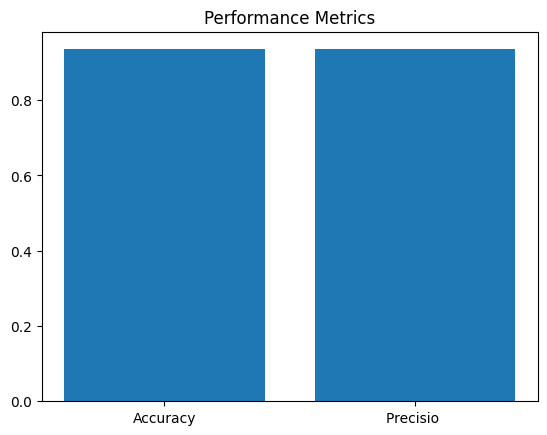

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x = ["Accuracy", "Precision"]
y = [total_accuracy, total_precision]

plt.bar(x,y)
plt.title("Performance Metrics")
plt.show()